In [1]:
"""
Week 2: Fundamentals of Image Processing - Complete Demo
Demonstrates core image processing techniques: filtering, blurring,
sharpening, edge detection, histograms, thresholding, morphological
operations, and affine transformations using synthetic data.
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import ndimage
from scipy.signal import convolve2d
import os

In [2]:
# ============================================================
# 配置常量
# Configuration Constants
# ============================================================
try:
    SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    SCRIPT_DIR = os.path.abspath(".")
OUTPUT_DIR = os.path.join(SCRIPT_DIR, "week2_image_processing_complete_demo_pages")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 图片尺寸和DPI
# Image dimensions and DPI
FIG_WIDTH = 12
FIG_HEIGHT = 8
DPI = 150
RANDOM_STATE = 42

# 滤波核大小
# Filter kernel sizes
KERNEL_SIZE_SMALL = 3
KERNEL_SIZE_MEDIUM = 5
KERNEL_SIZE_LARGE = 7

# Canny边缘检测阈值
# Canny edge detection thresholds
CANNY_LOW_THRESHOLD = 50
CANNY_HIGH_THRESHOLD = 150

# 阈值化参数
# Thresholding parameters
SIMPLE_THRESHOLD = 127
MAX_PIXEL_VALUE = 255
ADAPTIVE_BLOCK_SIZE = 11
ADAPTIVE_CONSTANT = 2

# 形态学核大小
# Morphological kernel size
MORPH_KERNEL_SIZE = 3

# 噪声参数
# Noise parameters
NOISE_SCALE = 25
SALT_PEPPER_RATIO = 0.02

np.random.seed(RANDOM_STATE)


# ============================================================
# 辅助函数：生成合成测试图像
# Helper: Generate synthetic test image
# ============================================================

def create_synthetic_image(size=128):
    """Create a synthetic grayscale test image with geometric shapes."""
    img = np.zeros((size, size), dtype=np.float64)

    # 背景渐变 / Background gradient
    for y in range(size):
        img[y, :] = 30 + (y / size) * 40

    # 矩形 / Rectangle
    img[20:50, 20:60] = 200

    # 圆形 / Circle
    cy, cx, radius = 80, 80, 20
    yy, xx = np.ogrid[:size, :size]
    circle_mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    img[circle_mask] = 180

    # 对角线 / Diagonal line
    for i in range(size):
        if 0 <= i < size:
            thickness = 2
            for t in range(-thickness, thickness + 1):
                row = i + t
                if 0 <= row < size:
                    img[row, i] = 220

    # 小方块（用于测试形态学）/ Small squares (for morphology testing)
    img[100:105, 10:15] = 200
    img[105:108, 50:53] = 200

    return np.clip(img, 0, 255).astype(np.uint8)


def add_gaussian_noise(img, scale=NOISE_SCALE):
    """Add Gaussian noise to an image."""
    noise = np.random.normal(0, scale, img.shape)
    noisy = img.astype(np.float64) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)


def add_salt_pepper_noise(img, ratio=SALT_PEPPER_RATIO):
    """Add salt-and-pepper noise to an image."""
    result = img.copy()
    # 盐噪声（白点）/ Salt noise (white dots)
    num_salt = int(ratio * img.size)
    salt_coords = (np.random.randint(0, img.shape[0], num_salt),
                   np.random.randint(0, img.shape[1], num_salt))
    result[salt_coords] = 255

    # 椒噪声（黑点）/ Pepper noise (black dots)
    num_pepper = int(ratio * img.size)
    pepper_coords = (np.random.randint(0, img.shape[0], num_pepper),
                     np.random.randint(0, img.shape[1], num_pepper))
    result[pepper_coords] = 0

    return result

Step 1: Convolution Operation — How Filters Work


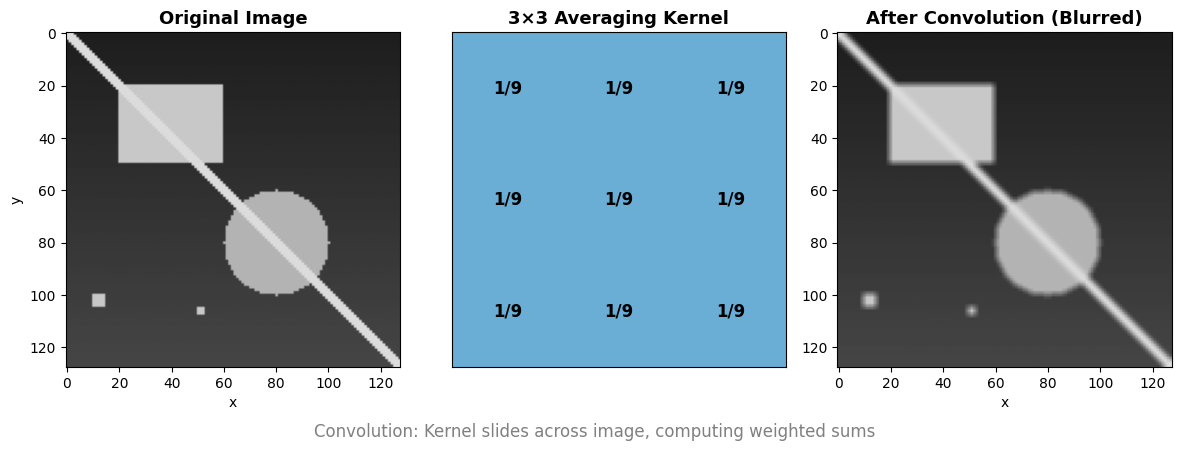

Original image shape: (128, 128)
Kernel: 3x3 averaging filter (each weight = 1/9)
Convolution replaces each pixel with the mean of its neighborhood

Saved: step1_convolution_demo.png


In [3]:
# ============================================================
# 步骤 1：卷积运算演示
# Step 1: Convolution Operation Demo
# ============================================================
print("=" * 60)
print("Step 1: Convolution Operation — How Filters Work")
print("=" * 60)

# 创建测试图像
# Create test image
test_img = create_synthetic_image()

# 均值核（3×3）：每个像素 = 邻域9个像素的平均
# Average kernel (3x3): each pixel = average of 9-pixel neighborhood
avg_kernel = np.ones((KERNEL_SIZE_SMALL, KERNEL_SIZE_SMALL)) / (KERNEL_SIZE_SMALL ** 2)

# 演示卷积过程
# Demonstrate convolution process
filtered_img = convolve2d(test_img.astype(np.float64), avg_kernel, mode='same', boundary='symm')
filtered_img = np.clip(filtered_img, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(FIG_WIDTH, FIG_HEIGHT // 2 + 1))

axes[0].set_title("Original Image", fontsize=13, fontweight='bold')
axes[0].imshow(test_img, cmap='gray', vmin=0, vmax=255)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# 显示卷积核
# Show kernel
axes[1].set_title("3×3 Averaging Kernel", fontsize=13, fontweight='bold')
kernel_display = avg_kernel * (KERNEL_SIZE_SMALL ** 2)
axes[1].imshow(kernel_display, cmap='Blues', vmin=0, vmax=2)
for i in range(KERNEL_SIZE_SMALL):
    for j in range(KERNEL_SIZE_SMALL):
        axes[1].text(j, i, f"1/{KERNEL_SIZE_SMALL**2}", ha='center', va='center',
                     fontsize=12, fontweight='bold', color='black')
axes[1].set_xticks([])
axes[1].set_yticks([])

axes[2].set_title("After Convolution (Blurred)", fontsize=13, fontweight='bold')
axes[2].imshow(filtered_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_xlabel("x")

plt.suptitle("Convolution: Kernel slides across image, computing weighted sums",
             fontsize=12, y=0.02, color='gray')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step1_convolution_demo.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Original image shape: {test_img.shape}")
print(f"Kernel: 3x3 averaging filter (each weight = 1/9)")
print(f"Convolution replaces each pixel with the mean of its neighborhood")
print("\nSaved: step1_convolution_demo.png")


Step 2: Blurring Comparison (Average vs Gaussian vs Median)


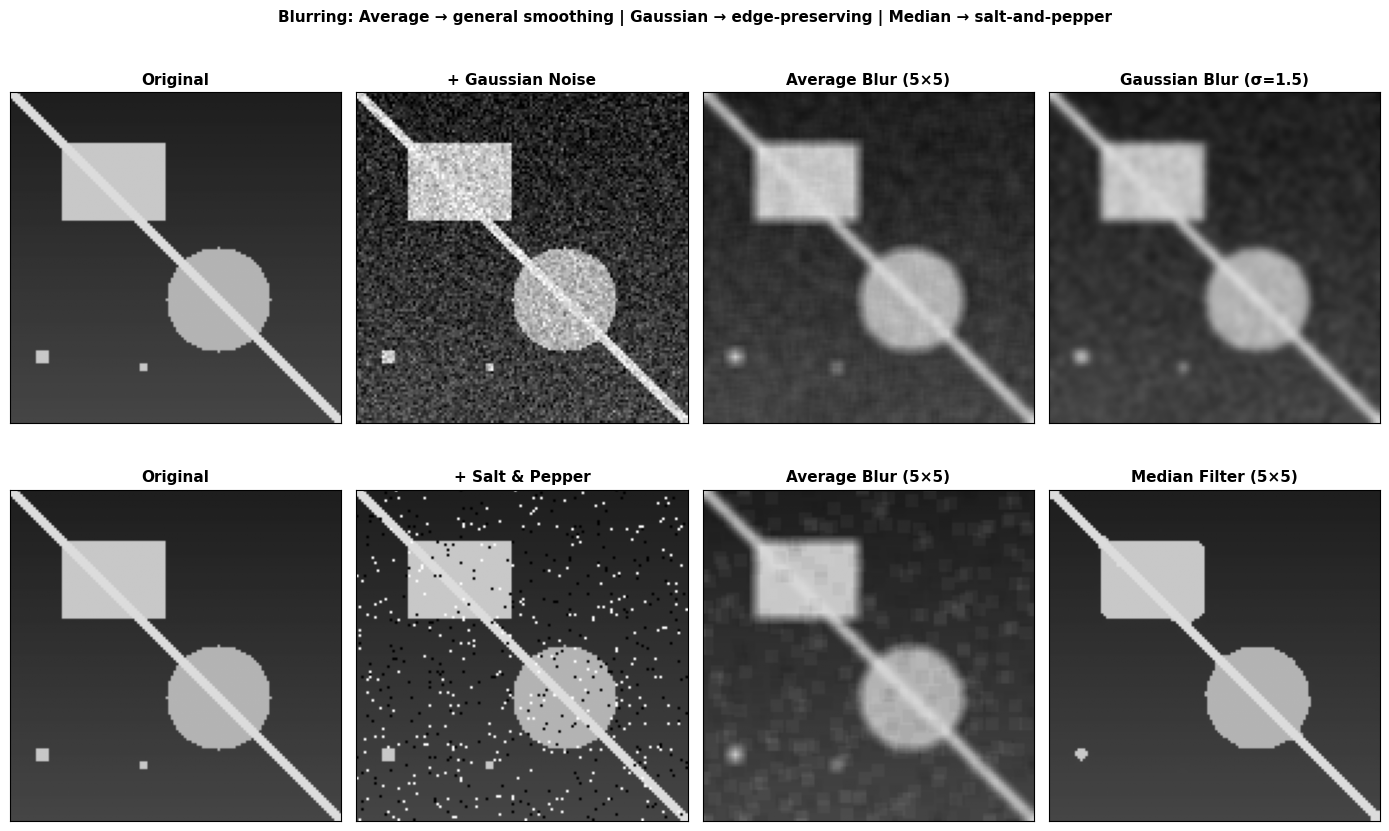

Average blur: Uniform weights, general smoothing
Gaussian blur: Bell-curve weights, preserves edges better
Median filter: Takes median value, best for salt-and-pepper noise

Saved: step2_blurring_comparison.png


In [4]:
# ============================================================
# 步骤 2：图像模糊对比（均值 vs 高斯 vs 中值）
# Step 2: Blurring Comparison (Average vs Gaussian vs Median)
# ============================================================
print("\n" + "=" * 60)
print("Step 2: Blurring Comparison (Average vs Gaussian vs Median)")
print("=" * 60)

# 添加不同类型噪声的图像
# Add different noise types
noisy_gaussian = add_gaussian_noise(test_img)
noisy_sp = add_salt_pepper_noise(test_img)

# 均值模糊 / Average (Box) blur
avg_kernel_5 = np.ones((KERNEL_SIZE_MEDIUM, KERNEL_SIZE_MEDIUM)) / (KERNEL_SIZE_MEDIUM ** 2)
avg_blurred = convolve2d(noisy_gaussian.astype(np.float64), avg_kernel_5,
                         mode='same', boundary='symm')
avg_blurred = np.clip(avg_blurred, 0, 255).astype(np.uint8)

# 高斯模糊 / Gaussian blur
gaussian_blurred = ndimage.gaussian_filter(noisy_gaussian, sigma=1.5)

# 中值滤波 / Median filter
median_filtered = ndimage.median_filter(noisy_sp, size=KERNEL_SIZE_MEDIUM)

fig, axes = plt.subplots(2, 4, figsize=(FIG_WIDTH + 2, FIG_HEIGHT + 1))

# 上排：高斯噪声 + 滤波
# Top row: Gaussian noise + filtering
axes[0, 0].set_title("Original", fontsize=11, fontweight='bold')
axes[0, 0].imshow(test_img, cmap='gray', vmin=0, vmax=255)

axes[0, 1].set_title("+ Gaussian Noise", fontsize=11, fontweight='bold')
axes[0, 1].imshow(noisy_gaussian, cmap='gray', vmin=0, vmax=255)

axes[0, 2].set_title("Average Blur (5×5)", fontsize=11, fontweight='bold')
axes[0, 2].imshow(avg_blurred, cmap='gray', vmin=0, vmax=255)

axes[0, 3].set_title("Gaussian Blur (σ=1.5)", fontsize=11, fontweight='bold')
axes[0, 3].imshow(gaussian_blurred, cmap='gray', vmin=0, vmax=255)

# 下排：椒盐噪声 + 中值滤波
# Bottom row: Salt-and-pepper noise + median filter
axes[1, 0].set_title("Original", fontsize=11, fontweight='bold')
axes[1, 0].imshow(test_img, cmap='gray', vmin=0, vmax=255)

axes[1, 1].set_title("+ Salt & Pepper", fontsize=11, fontweight='bold')
axes[1, 1].imshow(noisy_sp, cmap='gray', vmin=0, vmax=255)

axes[1, 2].set_title("Average Blur (5×5)", fontsize=11, fontweight='bold')
avg_sp = convolve2d(noisy_sp.astype(np.float64), avg_kernel_5,
                    mode='same', boundary='symm')
axes[1, 2].imshow(np.clip(avg_sp, 0, 255).astype(np.uint8), cmap='gray', vmin=0, vmax=255)

axes[1, 3].set_title("Median Filter (5×5)", fontsize=11, fontweight='bold')
axes[1, 3].imshow(median_filtered, cmap='gray', vmin=0, vmax=255)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Blurring: Average → general smoothing | Gaussian → edge-preserving | Median → salt-and-pepper",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step2_blurring_comparison.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Average blur: Uniform weights, general smoothing")
print("Gaussian blur: Bell-curve weights, preserves edges better")
print("Median filter: Takes median value, best for salt-and-pepper noise")
print("\nSaved: step2_blurring_comparison.png")


Step 3: Image Sharpening — Enhancing Edges


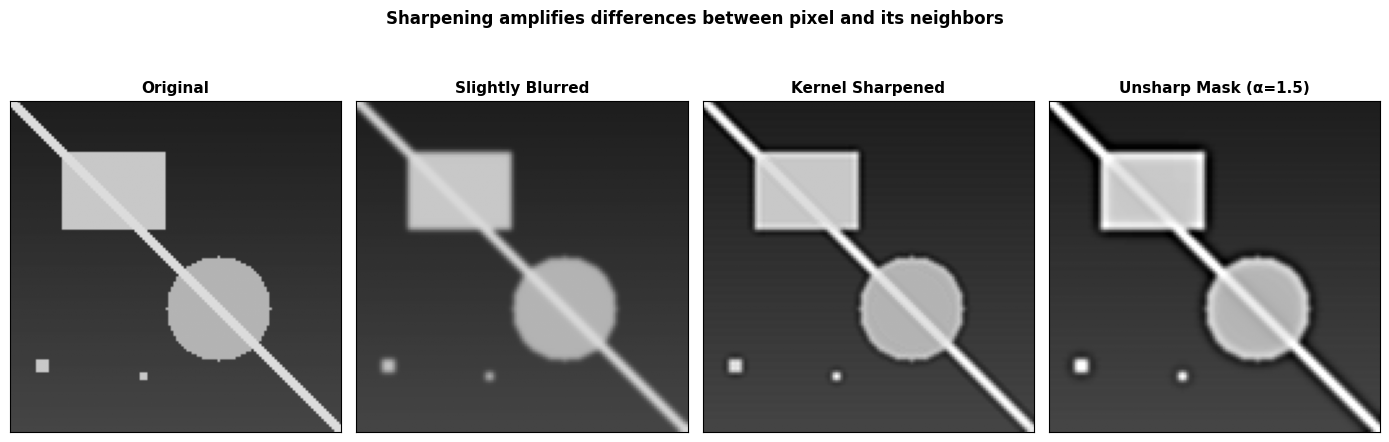

Sharpening kernel: [[0,-1,0],[-1,5,-1],[0,-1,0]]
Center (5) > sum of neighbors (-4) → amplifies edges
Unsharp masking: original + 1.5 × (original - blurred)

Saved: step3_sharpening.png


In [5]:
# ============================================================
# 步骤 3：图像锐化
# Step 3: Image Sharpening
# ============================================================
print("\n" + "=" * 60)
print("Step 3: Image Sharpening — Enhancing Edges")
print("=" * 60)

# 先对原图做轻微模糊（模拟失焦）
# Lightly blur the original (simulate out-of-focus)
slightly_blurred = ndimage.gaussian_filter(test_img, sigma=1.0)

# 锐化核：中心值大于邻居之和，放大差异
# Sharpening kernel: center > sum of neighbors, amplifies differences
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1,  5, -1],
    [0, -1, 0]
], dtype=np.float64)

sharpened = convolve2d(slightly_blurred.astype(np.float64), sharpen_kernel,
                       mode='same', boundary='symm')
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)

# 反锐化掩模方法：sharpened = original + alpha * (original - blurred)
# Unsharp masking: sharpened = original + alpha * (original - blurred)
UNSHARP_ALPHA = 1.5
unsharp_mask = slightly_blurred.astype(np.float64) + UNSHARP_ALPHA * (
    slightly_blurred.astype(np.float64) - ndimage.gaussian_filter(slightly_blurred, sigma=2.0)
)
unsharp_result = np.clip(unsharp_mask, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(FIG_WIDTH + 2, FIG_HEIGHT // 2 + 1))

axes[0].set_title("Original", fontsize=11, fontweight='bold')
axes[0].imshow(test_img, cmap='gray', vmin=0, vmax=255)

axes[1].set_title("Slightly Blurred", fontsize=11, fontweight='bold')
axes[1].imshow(slightly_blurred, cmap='gray', vmin=0, vmax=255)

axes[2].set_title("Kernel Sharpened", fontsize=11, fontweight='bold')
axes[2].imshow(sharpened, cmap='gray', vmin=0, vmax=255)

axes[3].set_title(f"Unsharp Mask (α={UNSHARP_ALPHA})", fontsize=11, fontweight='bold')
axes[3].imshow(unsharp_result, cmap='gray', vmin=0, vmax=255)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Sharpening amplifies differences between pixel and its neighbors",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step3_sharpening.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Sharpening kernel: [[0,-1,0],[-1,5,-1],[0,-1,0]]")
print(f"Center (5) > sum of neighbors (-4) → amplifies edges")
print(f"Unsharp masking: original + {UNSHARP_ALPHA} × (original - blurred)")
print("\nSaved: step3_sharpening.png")


Step 4: Basic Manipulations (Resize, Crop, Rotate)


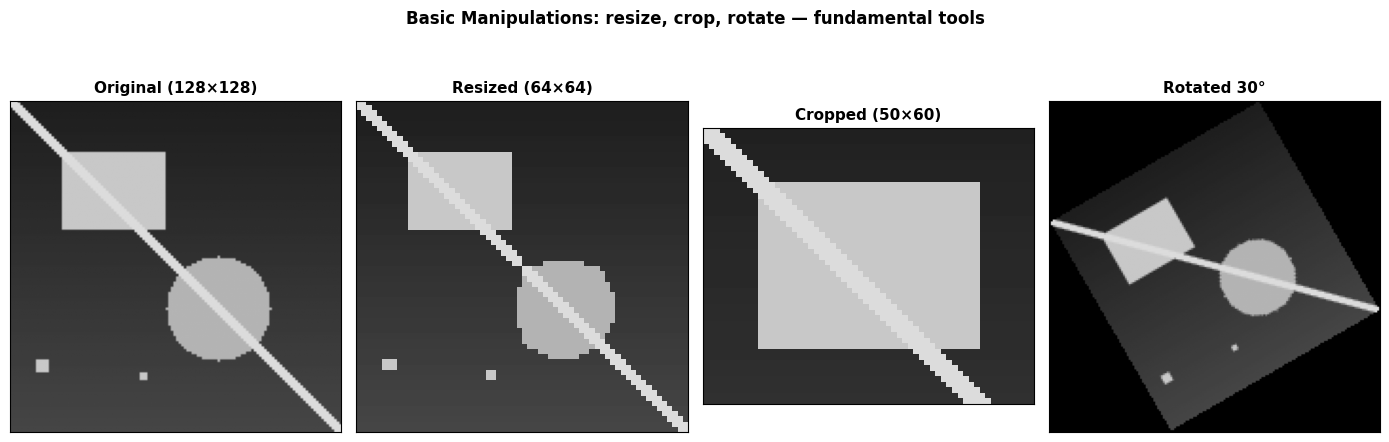

Resize: (128, 128) → (64, 64) (scale=0.5)
Crop: [10:60, 10:70] → (50, 60)
Rotate: 30° → (175, 175)

Saved: step4_basic_manipulations.png


In [6]:
# ============================================================
# 步骤 4：基本图像操作（缩放、裁剪、旋转）
# Step 4: Basic Manipulations (Resize, Crop, Rotate)
# ============================================================
print("\n" + "=" * 60)
print("Step 4: Basic Manipulations (Resize, Crop, Rotate)")
print("=" * 60)

# 缩放（最近邻插值）/ Resize (nearest-neighbor interpolation)
SCALE_FACTOR = 0.5
new_h = int(test_img.shape[0] * SCALE_FACTOR)
new_w = int(test_img.shape[1] * SCALE_FACTOR)
resized = ndimage.zoom(test_img, SCALE_FACTOR, order=0)

# 裁剪（numpy切片）/ Crop (numpy slicing)
CROP_Y1, CROP_Y2 = 10, 60
CROP_X1, CROP_X2 = 10, 70
cropped = test_img[CROP_Y1:CROP_Y2, CROP_X1:CROP_X2]

# 旋转 / Rotate
ROTATION_ANGLE = 30
rotated = ndimage.rotate(test_img, ROTATION_ANGLE, reshape=True, order=1, cval=0)

fig, axes = plt.subplots(1, 4, figsize=(FIG_WIDTH + 2, FIG_HEIGHT // 2 + 1))

axes[0].set_title(f"Original ({test_img.shape[0]}×{test_img.shape[1]})",
                  fontsize=11, fontweight='bold')
axes[0].imshow(test_img, cmap='gray', vmin=0, vmax=255)

axes[1].set_title(f"Resized ({resized.shape[0]}×{resized.shape[1]})",
                  fontsize=11, fontweight='bold')
axes[1].imshow(resized, cmap='gray', vmin=0, vmax=255)

axes[2].set_title(f"Cropped ({cropped.shape[0]}×{cropped.shape[1]})",
                  fontsize=11, fontweight='bold')
axes[2].imshow(cropped, cmap='gray', vmin=0, vmax=255)

axes[3].set_title(f"Rotated {ROTATION_ANGLE}°", fontsize=11, fontweight='bold')
axes[3].imshow(rotated, cmap='gray', vmin=0, vmax=255)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Basic Manipulations: resize, crop, rotate — fundamental tools",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step4_basic_manipulations.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Resize: {test_img.shape} → {resized.shape} (scale={SCALE_FACTOR})")
print(f"Crop: [{CROP_Y1}:{CROP_Y2}, {CROP_X1}:{CROP_X2}] → {cropped.shape}")
print(f"Rotate: {ROTATION_ANGLE}° → {rotated.shape}")
print("\nSaved: step4_basic_manipulations.png")


Step 5: Canny Edge Detection — 5 Stages


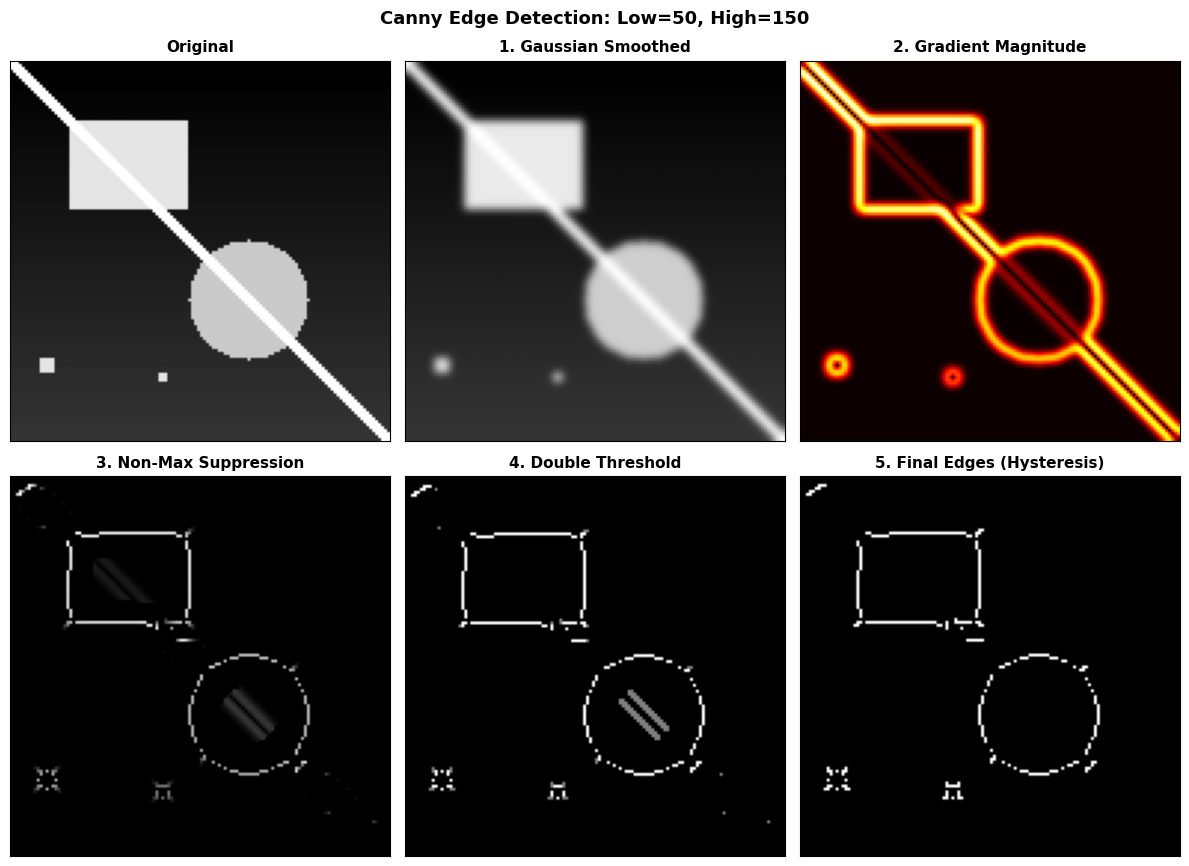

5 stages of Canny edge detection:
  1. Noise Reduction — Gaussian smoothing (σ=1.4)
  2. Gradient Calculation — Sobel kernels (horizontal + vertical)
  3. Non-maximum Suppression — Thin edges to 1-pixel width
  4. Double Thresholding — Low=50, High=150
  5. Edge Tracking by Hysteresis — Connect weak edges to strong edges

Saved: step5_canny_stages.png


In [7]:
# ============================================================
# 步骤 5：Canny边缘检测（5阶段分解）
# Step 5: Canny Edge Detection (5-Stage Breakdown)
# ============================================================
print("\n" + "=" * 60)
print("Step 5: Canny Edge Detection — 5 Stages")
print("=" * 60)

# 阶段1：高斯平滑降噪 / Stage 1: Gaussian smoothing
smoothed = ndimage.gaussian_filter(test_img.astype(np.float64), sigma=1.4)

# 阶段2：Sobel梯度计算 / Stage 2: Sobel gradient calculation
sobel_x = ndimage.sobel(smoothed, axis=1)
sobel_y = ndimage.sobel(smoothed, axis=0)
gradient_magnitude = np.hypot(sobel_x, sobel_y)
gradient_direction = np.arctan2(sobel_y, sobel_x)

# 阶段3：非极大值抑制 / Stage 3: Non-maximum suppression
nms = np.zeros_like(gradient_magnitude)
angle_deg = np.degrees(gradient_direction) % 180

for i in range(1, gradient_magnitude.shape[0] - 1):
    for j in range(1, gradient_magnitude.shape[1] - 1):
        a = angle_deg[i, j]
        mag = gradient_magnitude[i, j]
        # 根据梯度方向比较邻居 / Compare neighbors along gradient direction
        if (0 <= a < 22.5) or (157.5 <= a <= 180):
            n1, n2 = gradient_magnitude[i, j - 1], gradient_magnitude[i, j + 1]
        elif 22.5 <= a < 67.5:
            n1, n2 = gradient_magnitude[i - 1, j + 1], gradient_magnitude[i + 1, j - 1]
        elif 67.5 <= a < 112.5:
            n1, n2 = gradient_magnitude[i - 1, j], gradient_magnitude[i + 1, j]
        else:
            n1, n2 = gradient_magnitude[i - 1, j - 1], gradient_magnitude[i + 1, j + 1]
        if mag >= n1 and mag >= n2:
            nms[i, j] = mag

# 阶段4+5：双阈值 + 滞后跟踪 / Stage 4+5: Double threshold + hysteresis
strong_mask = nms >= CANNY_HIGH_THRESHOLD
weak_mask = (nms >= CANNY_LOW_THRESHOLD) & (nms < CANNY_HIGH_THRESHOLD)

# 简化的滞后跟踪：弱边缘连接到强边缘则保留
# Simplified hysteresis: keep weak edges connected to strong edges
canny_result = np.zeros_like(nms, dtype=np.uint8)
canny_result[strong_mask] = 255

# 迭代扩展：检查弱边缘是否与强边缘8-邻接
# Iterative expansion: check if weak edges are 8-connected to strong edges
from scipy.ndimage import binary_dilation
struct = np.ones((3, 3), dtype=bool)
for _ in range(5):
    dilated_strong = binary_dilation(canny_result > 0, structure=struct)
    new_edges = weak_mask & dilated_strong
    canny_result[new_edges] = 255
    if not np.any(new_edges):
        break

fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH, FIG_HEIGHT + 1))

axes[0, 0].set_title("Original", fontsize=11, fontweight='bold')
axes[0, 0].imshow(test_img, cmap='gray')

axes[0, 1].set_title("1. Gaussian Smoothed", fontsize=11, fontweight='bold')
axes[0, 1].imshow(smoothed, cmap='gray')

axes[0, 2].set_title("2. Gradient Magnitude", fontsize=11, fontweight='bold')
axes[0, 2].imshow(gradient_magnitude, cmap='hot')

axes[1, 0].set_title("3. Non-Max Suppression", fontsize=11, fontweight='bold')
axes[1, 0].imshow(nms, cmap='gray')

axes[1, 1].set_title("4. Double Threshold", fontsize=11, fontweight='bold')
threshold_vis = np.zeros_like(nms)
threshold_vis[weak_mask] = 128
threshold_vis[strong_mask] = 255
axes[1, 1].imshow(threshold_vis, cmap='gray')

axes[1, 2].set_title("5. Final Edges (Hysteresis)", fontsize=11, fontweight='bold')
axes[1, 2].imshow(canny_result, cmap='gray')

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f"Canny Edge Detection: Low={CANNY_LOW_THRESHOLD}, High={CANNY_HIGH_THRESHOLD}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step5_canny_stages.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("5 stages of Canny edge detection:")
print("  1. Noise Reduction — Gaussian smoothing (σ=1.4)")
print("  2. Gradient Calculation — Sobel kernels (horizontal + vertical)")
print("  3. Non-maximum Suppression — Thin edges to 1-pixel width")
print(f"  4. Double Thresholding — Low={CANNY_LOW_THRESHOLD}, High={CANNY_HIGH_THRESHOLD}")
print("  5. Edge Tracking by Hysteresis — Connect weak edges to strong edges")
print("\nSaved: step5_canny_stages.png")


Step 6: Image Histogram & Histogram Equalization


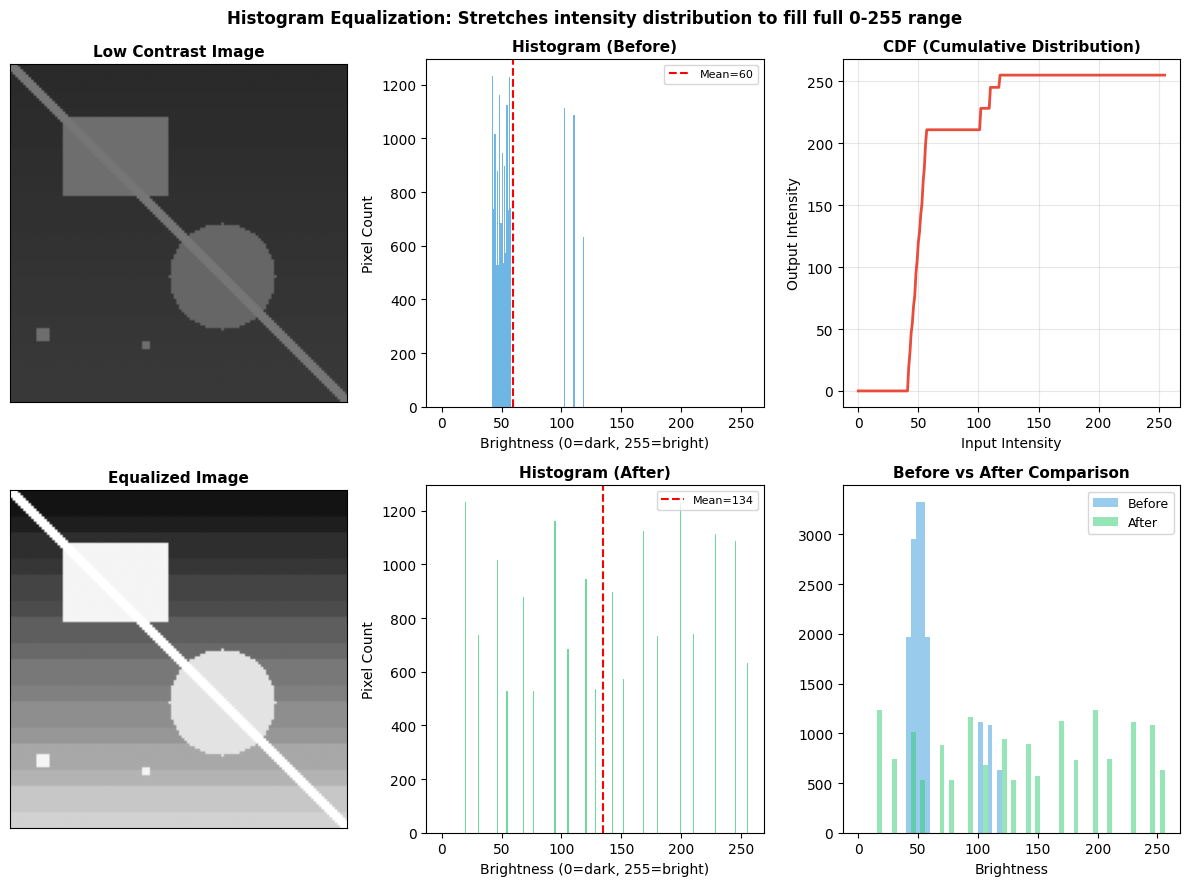

Low contrast image: mean=59.7, std=22.9
Equalized image:    mean=134.3, std=73.6
Histogram equalization spreads the distribution across 0-255

Saved: step6_histogram_equalization.png


In [8]:
# ============================================================
# 步骤 6：图像直方图与直方图均衡化
# Step 6: Image Histogram & Histogram Equalization
# ============================================================
print("\n" + "=" * 60)
print("Step 6: Image Histogram & Histogram Equalization")
print("=" * 60)

# 创建一个低对比度图像（模拟曝光不足）
# Create a low-contrast image (simulated underexposure)
low_contrast = np.clip(test_img.astype(np.float64) * 0.4 + 30, 0, 255).astype(np.uint8)

# 手动直方图均衡化 / Manual histogram equalization
hist, bins = np.histogram(low_contrast.flatten(), bins=256, range=(0, 256))
cdf = hist.cumsum()
# 归一化CDF / Normalize CDF
cdf_normalized = (cdf - cdf.min()) * 255 / (cdf.max() - cdf.min())
equalized = cdf_normalized[low_contrast].astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH, FIG_HEIGHT + 1))

axes[0, 0].set_title("Low Contrast Image", fontsize=11, fontweight='bold')
axes[0, 0].imshow(low_contrast, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])

axes[0, 1].set_title("Histogram (Before)", fontsize=11, fontweight='bold')
axes[0, 1].hist(low_contrast.flatten(), bins=256, range=(0, 256),
                color='#3498DB', alpha=0.7, edgecolor='none')
axes[0, 1].set_xlabel("Brightness (0=dark, 255=bright)")
axes[0, 1].set_ylabel("Pixel Count")
axes[0, 1].axvline(x=low_contrast.mean(), color='red', linestyle='--',
                    label=f'Mean={low_contrast.mean():.0f}')
axes[0, 1].legend(fontsize=8)

axes[0, 2].set_title("CDF (Cumulative Distribution)", fontsize=11, fontweight='bold')
axes[0, 2].plot(cdf_normalized, color='#E74C3C', linewidth=2)
axes[0, 2].set_xlabel("Input Intensity")
axes[0, 2].set_ylabel("Output Intensity")
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].set_title("Equalized Image", fontsize=11, fontweight='bold')
axes[1, 0].imshow(equalized, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_xticks([])
axes[1, 0].set_yticks([])

axes[1, 1].set_title("Histogram (After)", fontsize=11, fontweight='bold')
axes[1, 1].hist(equalized.flatten(), bins=256, range=(0, 256),
                color='#2ECC71', alpha=0.7, edgecolor='none')
axes[1, 1].set_xlabel("Brightness (0=dark, 255=bright)")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].axvline(x=equalized.mean(), color='red', linestyle='--',
                    label=f'Mean={equalized.mean():.0f}')
axes[1, 1].legend(fontsize=8)

axes[1, 2].set_title("Before vs After Comparison", fontsize=11, fontweight='bold')
axes[1, 2].hist(low_contrast.flatten(), bins=64, range=(0, 256),
                color='#3498DB', alpha=0.5, label='Before', edgecolor='none')
axes[1, 2].hist(equalized.flatten(), bins=64, range=(0, 256),
                color='#2ECC71', alpha=0.5, label='After', edgecolor='none')
axes[1, 2].legend(fontsize=9)
axes[1, 2].set_xlabel("Brightness")

plt.suptitle("Histogram Equalization: Stretches intensity distribution to fill full 0-255 range",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step6_histogram_equalization.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Low contrast image: mean={low_contrast.mean():.1f}, std={low_contrast.std():.1f}")
print(f"Equalized image:    mean={equalized.mean():.1f}, std={equalized.std():.1f}")
print("Histogram equalization spreads the distribution across 0-255")
print("\nSaved: step6_histogram_equalization.png")


Step 7: Image Thresholding (Simple vs Adaptive vs Otsu)


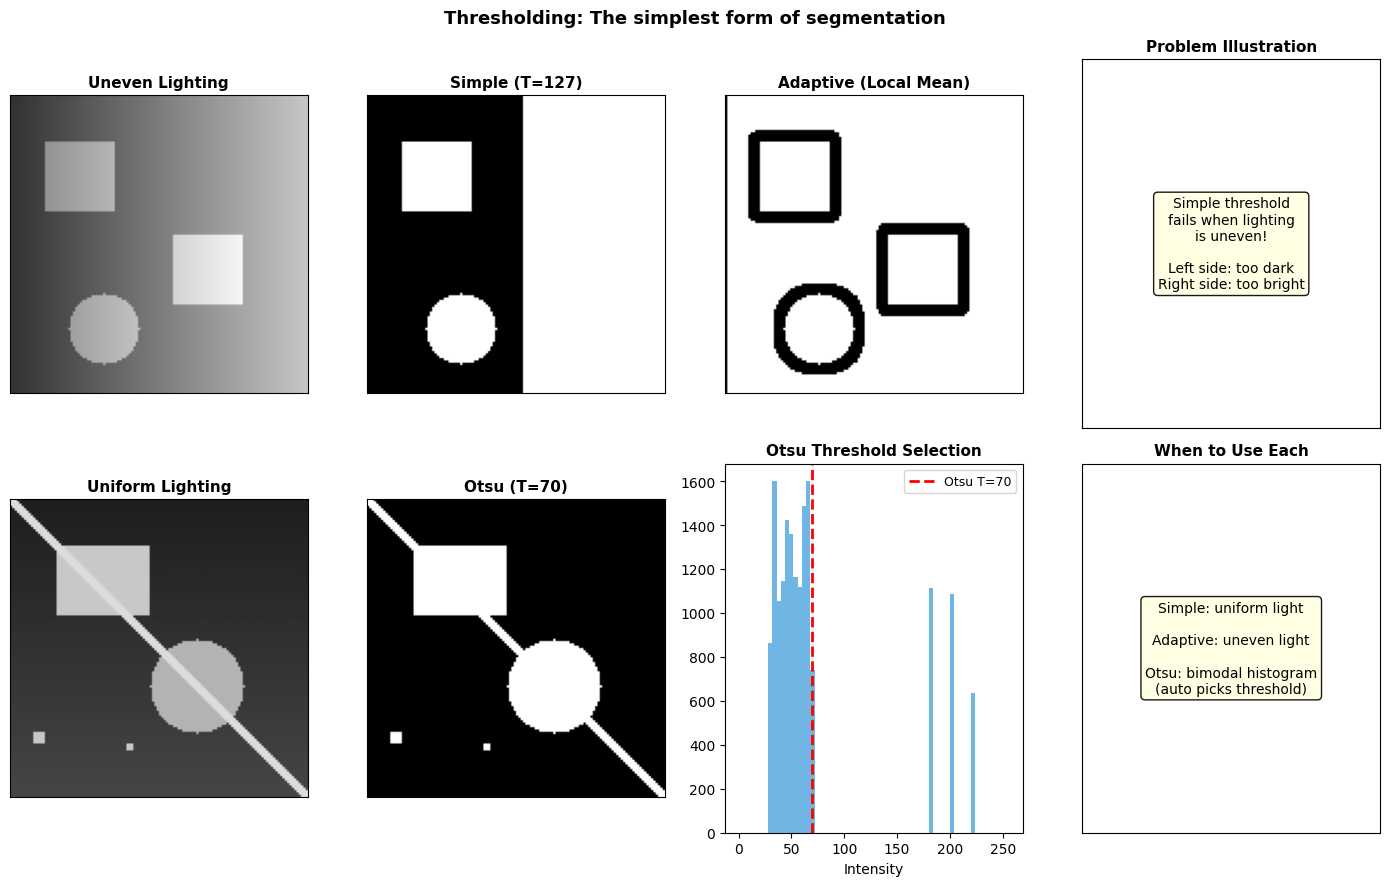

Simple threshold at T=127: fails under uneven lighting
Adaptive threshold (block=11): handles uneven lighting
Otsu auto-threshold: T=70 (maximizes inter-class variance)

Saved: step7_thresholding.png


In [9]:
# ============================================================
# 步骤 7：图像阈值化（简单 vs 自适应 vs Otsu）
# Step 7: Image Thresholding (Simple vs Adaptive vs Otsu)
# ============================================================
print("\n" + "=" * 60)
print("Step 7: Image Thresholding (Simple vs Adaptive vs Otsu)")
print("=" * 60)

# 创建光照不均匀的图像 / Create unevenly illuminated image
gradient_light = np.zeros((128, 128), dtype=np.float64)
for x in range(128):
    gradient_light[:, x] = 50 + (x / 128) * 150

# 添加前景对象 / Add foreground objects
uneven_img = gradient_light.copy()
uneven_img[20:50, 15:45] = gradient_light[20:50, 15:45] + 80
uneven_img[60:90, 70:100] = gradient_light[60:90, 70:100] + 80
cy, cx, r = 100, 40, 15
yy, xx = np.ogrid[:128, :128]
circle = (xx - cx) ** 2 + (yy - cy) ** 2 <= r ** 2
uneven_img[circle] = gradient_light[circle] + 80
uneven_img = np.clip(uneven_img, 0, 255).astype(np.uint8)

# 简单阈值 / Simple threshold
simple_thresh = (uneven_img > SIMPLE_THRESHOLD).astype(np.uint8) * MAX_PIXEL_VALUE

# 自适应阈值（局部均值法）/ Adaptive threshold (local mean method)
local_mean = ndimage.uniform_filter(uneven_img.astype(np.float64), size=ADAPTIVE_BLOCK_SIZE)
adaptive_thresh = (uneven_img > (local_mean - ADAPTIVE_CONSTANT)).astype(np.uint8) * MAX_PIXEL_VALUE

# Otsu自动阈值 / Otsu automatic threshold
hist_otsu, _ = np.histogram(test_img.flatten(), bins=256, range=(0, 256))
total_pixels = test_img.size
best_threshold = 0
max_variance = 0
for t in range(256):
    w0 = hist_otsu[:t].sum() / total_pixels
    w1 = hist_otsu[t:].sum() / total_pixels
    if w0 == 0 or w1 == 0:
        continue
    m0 = np.sum(np.arange(t) * hist_otsu[:t]) / hist_otsu[:t].sum()
    m1 = np.sum(np.arange(t, 256) * hist_otsu[t:]) / hist_otsu[t:].sum()
    variance = w0 * w1 * (m0 - m1) ** 2
    if variance > max_variance:
        max_variance = variance
        best_threshold = t

otsu_result = (test_img > best_threshold).astype(np.uint8) * MAX_PIXEL_VALUE

fig, axes = plt.subplots(2, 4, figsize=(FIG_WIDTH + 2, FIG_HEIGHT + 1))

# 上排：光照不均匀场景
# Top row: Uneven illumination scenario
axes[0, 0].set_title("Uneven Lighting", fontsize=11, fontweight='bold')
axes[0, 0].imshow(uneven_img, cmap='gray', vmin=0, vmax=255)

axes[0, 1].set_title(f"Simple (T={SIMPLE_THRESHOLD})", fontsize=11, fontweight='bold')
axes[0, 1].imshow(simple_thresh, cmap='gray', vmin=0, vmax=255)

axes[0, 2].set_title("Adaptive (Local Mean)", fontsize=11, fontweight='bold')
axes[0, 2].imshow(adaptive_thresh, cmap='gray', vmin=0, vmax=255)

axes[0, 3].set_title("Problem Illustration", fontsize=11, fontweight='bold')
axes[0, 3].text(0.5, 0.5, "Simple threshold\nfails when lighting\nis uneven!\n\n"
                "Left side: too dark\nRight side: too bright",
                ha='center', va='center', fontsize=10, transform=axes[0, 3].transAxes,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[0, 3].set_xticks([])
axes[0, 3].set_yticks([])

# 下排：Otsu场景（均匀光照）
# Bottom row: Otsu scenario (uniform lighting)
axes[1, 0].set_title("Uniform Lighting", fontsize=11, fontweight='bold')
axes[1, 0].imshow(test_img, cmap='gray', vmin=0, vmax=255)

axes[1, 1].set_title(f"Otsu (T={best_threshold})", fontsize=11, fontweight='bold')
axes[1, 1].imshow(otsu_result, cmap='gray', vmin=0, vmax=255)

axes[1, 2].set_title("Otsu Threshold Selection", fontsize=11, fontweight='bold')
axes[1, 2].hist(test_img.flatten(), bins=64, range=(0, 256), color='#3498DB',
                alpha=0.7, edgecolor='none')
axes[1, 2].axvline(x=best_threshold, color='red', linewidth=2, linestyle='--',
                    label=f'Otsu T={best_threshold}')
axes[1, 2].legend(fontsize=9)
axes[1, 2].set_xlabel("Intensity")

axes[1, 3].set_title("When to Use Each", fontsize=11, fontweight='bold')
axes[1, 3].text(0.5, 0.5, "Simple: uniform light\n\n"
                "Adaptive: uneven light\n\n"
                "Otsu: bimodal histogram\n(auto picks threshold)",
                ha='center', va='center', fontsize=10, transform=axes[1, 3].transAxes,
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[1, 3].set_xticks([])
axes[1, 3].set_yticks([])

for ax in axes.flat:
    if len(ax.images) > 0:
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Thresholding: The simplest form of segmentation",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step7_thresholding.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print(f"Simple threshold at T={SIMPLE_THRESHOLD}: fails under uneven lighting")
print(f"Adaptive threshold (block={ADAPTIVE_BLOCK_SIZE}): handles uneven lighting")
print(f"Otsu auto-threshold: T={best_threshold} (maximizes inter-class variance)")
print("\nSaved: step7_thresholding.png")


Step 8: Morphological Operations


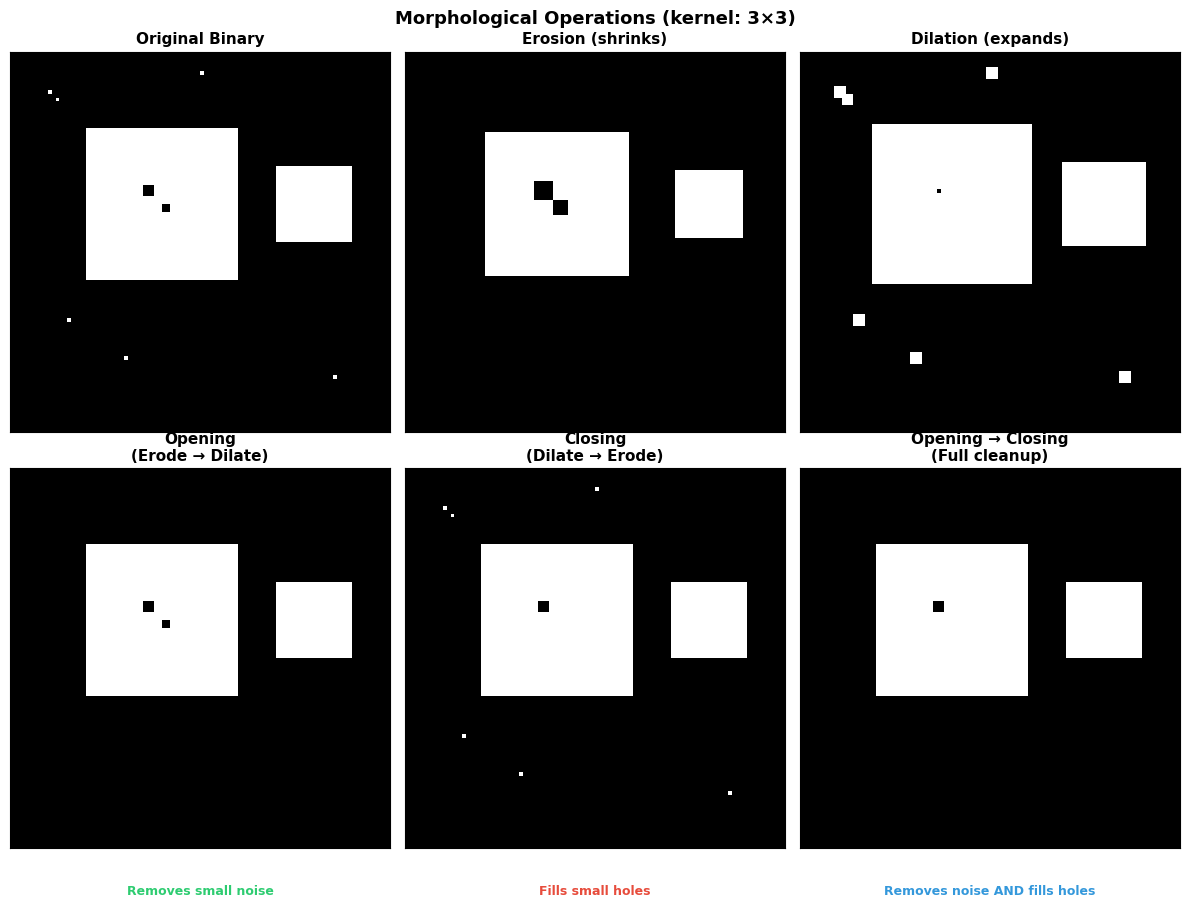

Erosion: shrinks objects, removes small noise (ALL must be 1)
Dilation: expands objects, fills gaps (AT LEAST ONE must be 1)
Opening = Erode → Dilate: removes small white noise
Closing = Dilate → Erode: fills small black holes
Order matters! Opening ≠ Closing

Saved: step8_morphological_ops.png


In [10]:
# ============================================================
# 步骤 8：形态学操作（腐蚀、膨胀、开运算、闭运算）
# Step 8: Morphological Operations (Erosion, Dilation, Opening, Closing)
# ============================================================
print("\n" + "=" * 60)
print("Step 8: Morphological Operations")
print("=" * 60)

# 创建带有噪声和孔洞的二值图像
# Create binary image with noise and holes
binary_img = np.zeros((100, 100), dtype=np.uint8)
binary_img[20:60, 20:60] = 255
binary_img[30:50, 70:90] = 255

# 添加小白噪声点 / Add small white noise dots
binary_img[10, 10] = 255
binary_img[12, 12] = 255
binary_img[80, 30] = 255
binary_img[85, 85] = 255
binary_img[5, 50] = 255
binary_img[70, 15] = 255

# 添加小黑孔洞在对象内 / Add small black holes inside objects
binary_img[35:38, 35:38] = 0
binary_img[40:42, 40:42] = 0

morph_kernel = np.ones((MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE), dtype=np.uint8)

# 腐蚀：核下所有像素为1才保持1 / Erosion: all pixels under kernel must be 1
eroded = ndimage.binary_erosion(binary_img > 0, structure=morph_kernel).astype(np.uint8) * 255

# 膨胀：核下至少一个像素为1就变为1 / Dilation: at least one pixel under kernel = 1
dilated = ndimage.binary_dilation(binary_img > 0, structure=morph_kernel).astype(np.uint8) * 255

# 开运算 = 腐蚀 → 膨胀 / Opening = erosion → dilation
opened = ndimage.binary_opening(binary_img > 0, structure=morph_kernel).astype(np.uint8) * 255

# 闭运算 = 膨胀 → 腐蚀 / Closing = dilation → erosion
closed = ndimage.binary_closing(binary_img > 0, structure=morph_kernel).astype(np.uint8) * 255

fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH, FIG_HEIGHT + 1))

axes[0, 0].set_title("Original Binary", fontsize=11, fontweight='bold')
axes[0, 0].imshow(binary_img, cmap='gray', vmin=0, vmax=255)

axes[0, 1].set_title("Erosion (shrinks)", fontsize=11, fontweight='bold')
axes[0, 1].imshow(eroded, cmap='gray', vmin=0, vmax=255)

axes[0, 2].set_title("Dilation (expands)", fontsize=11, fontweight='bold')
axes[0, 2].imshow(dilated, cmap='gray', vmin=0, vmax=255)

axes[1, 0].set_title("Opening\n(Erode → Dilate)", fontsize=11, fontweight='bold')
axes[1, 0].imshow(opened, cmap='gray', vmin=0, vmax=255)
axes[1, 0].text(0.5, -0.12, "Removes small noise", ha='center', fontsize=9,
                color='#2ECC71', transform=axes[1, 0].transAxes, fontweight='bold')

axes[1, 1].set_title("Closing\n(Dilate → Erode)", fontsize=11, fontweight='bold')
axes[1, 1].imshow(closed, cmap='gray', vmin=0, vmax=255)
axes[1, 1].text(0.5, -0.12, "Fills small holes", ha='center', fontsize=9,
                color='#E74C3C', transform=axes[1, 1].transAxes, fontweight='bold')

axes[1, 2].set_title("Opening → Closing\n(Full cleanup)", fontsize=11, fontweight='bold')
full_cleanup = ndimage.binary_closing(
    ndimage.binary_opening(binary_img > 0, structure=morph_kernel),
    structure=morph_kernel
).astype(np.uint8) * 255
axes[1, 2].imshow(full_cleanup, cmap='gray', vmin=0, vmax=255)
axes[1, 2].text(0.5, -0.12, "Removes noise AND fills holes", ha='center', fontsize=9,
                color='#3498DB', transform=axes[1, 2].transAxes, fontweight='bold')

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f"Morphological Operations (kernel: {MORPH_KERNEL_SIZE}×{MORPH_KERNEL_SIZE})",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step8_morphological_ops.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Erosion: shrinks objects, removes small noise (ALL must be 1)")
print("Dilation: expands objects, fills gaps (AT LEAST ONE must be 1)")
print("Opening = Erode → Dilate: removes small white noise")
print("Closing = Dilate → Erode: fills small black holes")
print("Order matters! Opening ≠ Closing")
print("\nSaved: step8_morphological_ops.png")


Step 9: Affine Transformations — y = Ax + b


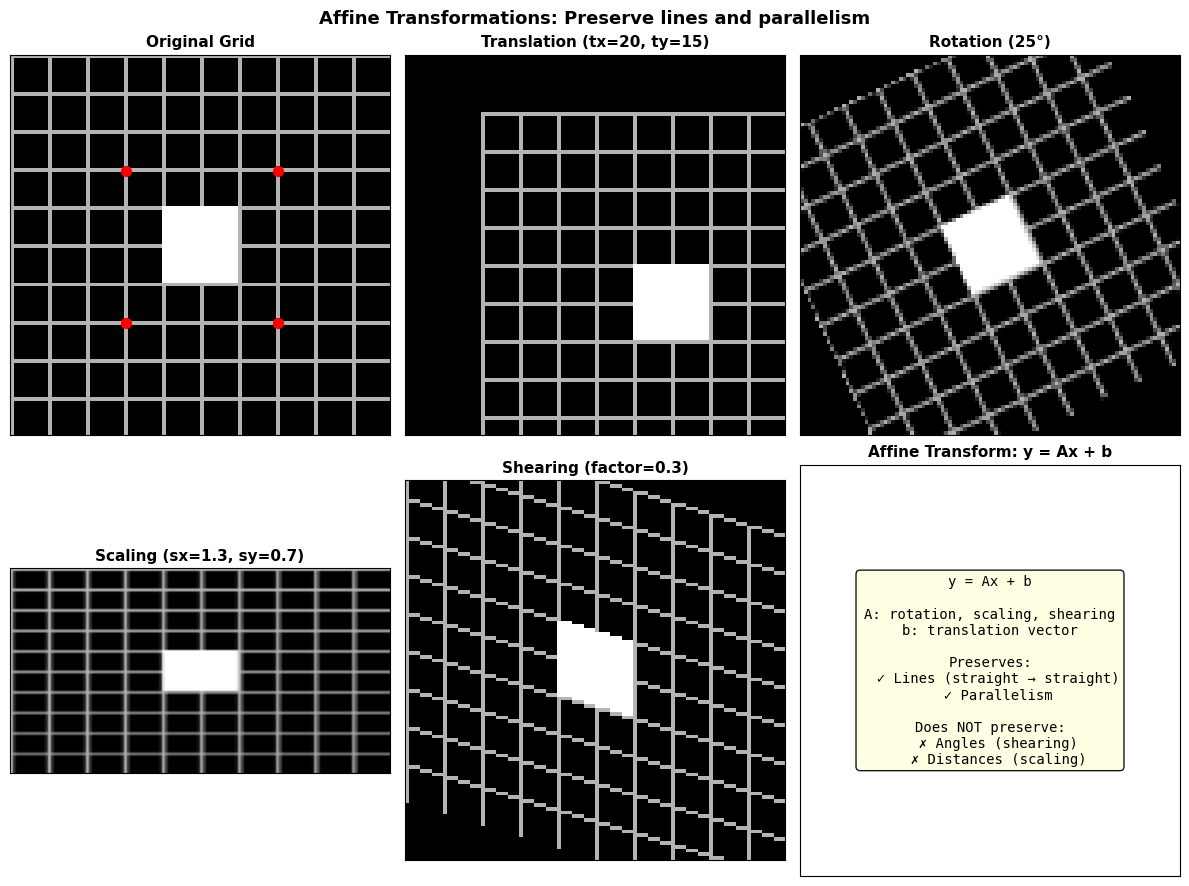

Affine transformation formula: y = Ax + b
  Translation: shift by (tx=20, ty=15)
  Rotation: 25° around center
  Scaling: sx=1.3, sy=0.7
  Shearing: factor=0.3
Preserves: lines and parallelism
Does NOT preserve: angles (shearing) or distances (scaling)

Saved: step9_affine_transforms.png

All demos completed successfully!
Output directory: D:\BaiduSyncdisk\workspace\python_workspace_2025\aisd\courses\mv\notes\week2_image_processing_complete_demo_pages


In [11]:
# ============================================================
# 步骤 9：仿射变换（平移、旋转、缩放、剪切）
# Step 9: Affine Transformations (Translation, Rotation, Scaling, Shearing)
# ============================================================
print("\n" + "=" * 60)
print("Step 9: Affine Transformations — y = Ax + b")
print("=" * 60)

# 创建参考网格图（更好展示变换效果）
# Create reference grid image (better shows transformation effects)
grid_size = 100
grid_img = np.zeros((grid_size, grid_size), dtype=np.uint8)
GRID_SPACING = 10
for i in range(0, grid_size, GRID_SPACING):
    grid_img[i, :] = 180
    grid_img[:, i] = 180
grid_img[40:60, 40:60] = 255

# 定义原始点（用于显示变换前后）
# Define original points (to show before/after transformation)
original_points = np.array([[30, 30], [30, 70], [70, 30], [70, 70]], dtype=np.float64)

fig, axes = plt.subplots(2, 3, figsize=(FIG_WIDTH, FIG_HEIGHT + 1))

# 原图 / Original
axes[0, 0].set_title("Original Grid", fontsize=11, fontweight='bold')
axes[0, 0].imshow(grid_img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].scatter(original_points[:, 1], original_points[:, 0],
                    c='red', s=50, zorder=5)

# 平移 / Translation
TX, TY = 20, 15
translated = ndimage.shift(grid_img, [TY, TX], order=0, cval=0)
axes[0, 1].set_title(f"Translation (tx={TX}, ty={TY})", fontsize=11, fontweight='bold')
axes[0, 1].imshow(translated, cmap='gray', vmin=0, vmax=255)

# 旋转 / Rotation
AFFINE_ROTATION_ANGLE = 25
affine_rotated = ndimage.rotate(grid_img, AFFINE_ROTATION_ANGLE, reshape=False, order=1, cval=0)
axes[0, 2].set_title(f"Rotation ({AFFINE_ROTATION_ANGLE}°)", fontsize=11, fontweight='bold')
axes[0, 2].imshow(affine_rotated, cmap='gray', vmin=0, vmax=255)

# 缩放 / Scaling
SCALE_X, SCALE_Y = 1.3, 0.7
scaled = ndimage.zoom(grid_img, [SCALE_Y, SCALE_X], order=1)
axes[1, 0].set_title(f"Scaling (sx={SCALE_X}, sy={SCALE_Y})", fontsize=11, fontweight='bold')
axes[1, 0].imshow(scaled, cmap='gray', vmin=0, vmax=255)

# 剪切 / Shearing
SHEAR_FACTOR = 0.3
shear_matrix = np.array([[1, SHEAR_FACTOR], [0, 1]])
coords = np.mgrid[0:grid_size, 0:grid_size].reshape(2, -1).astype(np.float64)
center = np.array([[grid_size / 2], [grid_size / 2]])
coords_centered = coords - center
new_coords = shear_matrix @ coords_centered + center
sheared = np.zeros_like(grid_img)
valid = (new_coords[0] >= 0) & (new_coords[0] < grid_size) & \
        (new_coords[1] >= 0) & (new_coords[1] < grid_size)
src_flat = grid_img.flatten()
for idx in range(len(valid.flatten())):
    if valid.flatten()[idx]:
        ny, nx = int(new_coords[0].flatten()[idx]), int(new_coords[1].flatten()[idx])
        if 0 <= ny < grid_size and 0 <= nx < grid_size:
            sheared[ny, nx] = src_flat[idx]

axes[1, 1].set_title(f"Shearing (factor={SHEAR_FACTOR})", fontsize=11, fontweight='bold')
axes[1, 1].imshow(sheared, cmap='gray', vmin=0, vmax=255)

# 总结 / Summary
axes[1, 2].set_title("Affine Transform: y = Ax + b", fontsize=11, fontweight='bold')
axes[1, 2].text(0.5, 0.5,
                "y = Ax + b\n\n"
                "A: rotation, scaling, shearing\n"
                "b: translation vector\n\n"
                "Preserves:\n"
                "  ✓ Lines (straight → straight)\n"
                "  ✓ Parallelism\n\n"
                "Does NOT preserve:\n"
                "  ✗ Angles (shearing)\n"
                "  ✗ Distances (scaling)",
                ha='center', va='center', fontsize=10,
                transform=axes[1, 2].transAxes, fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
axes[1, 2].set_xticks([])
axes[1, 2].set_yticks([])

for ax_row in axes:
    for ax in ax_row:
        if len(ax.images) > 0:
            ax.set_xticks([])
            ax.set_yticks([])

plt.suptitle("Affine Transformations: Preserve lines and parallelism",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "step9_affine_transforms.png"), dpi=DPI, bbox_inches='tight')
plt.show()

print("Affine transformation formula: y = Ax + b")
print(f"  Translation: shift by (tx={TX}, ty={TY})")
print(f"  Rotation: {AFFINE_ROTATION_ANGLE}° around center")
print(f"  Scaling: sx={SCALE_X}, sy={SCALE_Y}")
print(f"  Shearing: factor={SHEAR_FACTOR}")
print("Preserves: lines and parallelism")
print("Does NOT preserve: angles (shearing) or distances (scaling)")
print("\nSaved: step9_affine_transforms.png")

# ============================================================
# 完成
# Done
# ============================================================

print("\n" + "=" * 60)
print("All demos completed successfully!")
print(f"Output directory: {OUTPUT_DIR}")
print("=" * 60)